# Multi-satellite trajectory tie-in experiment

This notebook implements a batch tie-in experiment for six reference satellites. The tracking event is only a convenient way to choose two comparable historical telemetry records; the loss function itself uses GCRS state residuals at the selected epochs and dynamic consistency between those epochs.

The workflow is:

1. Load native historical position/velocity records for all six satellites used in `residual_addition_study.ipynb`.
2. Find two consecutive same-direction crossings of the configured latitude/longitude. Same-direction crossings should be separated by approximately one orbital period.
3. Use `scipy.optimize.least_squares` to refine the two GCRS states and ballistic parameters without adding synthetic noise to the historical data.
4. Forecast 12 hours from the second measurement, which is defined as `t = 0`, and compare a baseline model against the optimized tie-in model for all satellites.

In [1]:
import os
import sys
import subprocess
from pathlib import Path

IN_COLAB = 'google.colab' in sys.modules
REPO_URL = 'https://github.com/Gavr101/space_modeling.git'


def run(cmd):
    print('>>', ' '.join(map(str, cmd)))
    subprocess.check_call(cmd)


def find_project_root(start):
    start = Path(start).resolve()
    for candidate in (start, *start.parents):
        if (candidate / 'dynamics').is_dir() and (candidate / 'visualization').is_dir():
            return candidate
    raise RuntimeError(f'Cannot find project root from {start}')


if IN_COLAB:
    PROJECT_ROOT = Path('/content/space_modeling')
    if not PROJECT_ROOT.exists():
        run(['git', 'clone', REPO_URL, str(PROJECT_ROOT)])
    os.chdir(PROJECT_ROOT)
    run([sys.executable, '-m', 'pip', 'install', '--upgrade', 'pip'])
    run([sys.executable, '-m', 'pip', 'install', '-r', 'requirements.txt'])
    run([sys.executable, '-m', 'pip', 'install', '-e', '.'])
else:
    PROJECT_ROOT = find_project_root(Path.cwd())
    os.chdir(PROJECT_ROOT)

if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

print('Working dir:', PROJECT_ROOT)

Working dir: C:\Users\Gavriil\VS_projects\space_modeling


In [2]:
import matplotlib.pyplot as plt
import numpy as np
from astropy import units as u
from astropy.coordinates import GCRS, ITRS, CartesianRepresentation
from scipy.optimize import least_squares

from dynamics.eof import read_sentinel_eof
from dynamics.force_models import ForceModelConfig
from dynamics.propagator import PropagationConfig, SpacecraftProperties, propagate_orbit
from dynamics.sp3 import download_sp3, itrs_states_to_gcrs, read_sp3, sp3_velocity_records

## Experiment configuration

The force model mirrors `prediction_error_growth_demo.ipynb`: J2, drag, Sun/Moon third bodies, and SRP are enabled. The measurement weights below are covariance assumptions for the least-squares objective, not random perturbations applied to the historical states.

In [3]:
EARTH_RADIUS_M = 6_378_137.0
EARTH_MU_M3_S2 = 3.986004418e14
DATA_DIR = PROJECT_ROOT / 'data'

CROSSING_MODE = 'latitude'  # 'latitude' or 'longitude'
TARGET_LATITUDE_DEG = 67.5641
TARGET_LONGITUDE_DEG = 67.5641
CROSSING_DIRECTION = 'ascending'  # Same direction gives roughly one orbit between consecutive crossings.
N_MEASUREMENTS = 2
LAST_CROSSING_AFTER_H = 6.0
ORBIT_PERIOD_REL_TOL = 0.25

FORECAST_HOURS = 12.0
PROPAGATION_STEP_SECONDS = 120.0
REFERENCE_DURATION_HOURS = LAST_CROSSING_AFTER_H + FORECAST_HOURS + 4.0

POSITION_OBSERVATION_SIGMA_M = 250.0
VELOCITY_OBSERVATION_SIGMA_M_S = 0.08
DYNAMIC_POSITION_SIGMA_M = 150.0
DYNAMIC_VELOCITY_SIGMA_M_S = 0.05
PARAMETER_LOG_SIGMA = np.log(1.25)
MAX_NFEV = 35

VELOCITY_REFERENCE_SOURCES = {
    'Sentinel-1A': {
        'format': 'sentinel_eof',
        'url': 'https://s1-orbits.s3.us-west-2.amazonaws.com/AUX_POEORB/S1A_OPER_AUX_POEORB_OPOD_20230821T080724_V20230731T225942_20230802T005942.EOF',
        'path': DATA_DIR / 'eof' / 'S1A_OPER_AUX_POEORB_OPOD_20230821T080724_V20230731T225942_20230802T005942.EOF',
        'spacecraft': SpacecraftProperties(mass=2185.0, cd=2.2, cr=1.3, reference_area=10.3),
    },
    'Sentinel-1B': {
        'format': 'sentinel_eof',
        'url': 'https://s1-orbits.s3.us-west-2.amazonaws.com/AUX_POEORB/S1B_OPER_AUX_POEORB_OPOD_20210203T112353_V20210113T225942_20210115T005942.EOF',
        'path': DATA_DIR / 'eof' / 'S1B_OPER_AUX_POEORB_OPOD_20210203T112353_V20210113T225942_20210115T005942.EOF',
        'spacecraft': SpacecraftProperties(mass=2185.0, cd=2.2, cr=1.3, reference_area=10.3),
    },
    'CASSIOPE / Swarm-E': {
        'format': 'sp3',
        'satellite_id': 'L63',
        'url': 'https://epop-data.phys.ucalgary.ca/2017/02/01/CAS_Orbit_GEO_20170201T000000_20170201T235959_1.1.0.sp3.zip',
        'path': DATA_DIR / 'sp3' / 'CAS_Orbit_GEO_20170201T000000_20170201T235959_1.1.0.sp3.zip',
        'spacecraft': SpacecraftProperties(mass=500.0, cd=2.2, cr=1.3, reference_area=2.2),
    },
    'Swarm B': {
        'format': 'sp3',
        'satellite_id': 'L48',
        'url': 'https://swarm-diss.eo.esa.int/?do=download&file=swarm%2FLevel2daily%2FLatest_baselines%2FPOD%2FRD%2FSat_B%2FSW_OPER_SP3BCOM_2__20240106T235942_20240107T235942_0201.ZIP',
        'path': DATA_DIR / 'sp3' / 'SW_OPER_SP3BCOM_2__20240106T235942_20240107T235942_0201.ZIP',
        'spacecraft': SpacecraftProperties(mass=438.0, cd=2.2, cr=1.3, reference_area=1.1),
    },
    'Swarm C': {
        'format': 'sp3',
        'satellite_id': 'L49',
        'url': 'https://swarm-diss.eo.esa.int/?do=download&file=swarm%2FLevel2daily%2FLatest_baselines%2FPOD%2FRD%2FSat_C%2FSW_OPER_SP3CCOM_2__20240106T235942_20240107T235942_0201.ZIP',
        'path': DATA_DIR / 'sp3' / 'SW_OPER_SP3CCOM_2__20240106T235942_20240107T235942_0201.ZIP',
        'spacecraft': SpacecraftProperties(mass=438.0, cd=2.2, cr=1.3, reference_area=1.1),
    },
    'Swarm A': {
        'format': 'sp3',
        'satellite_id': 'L47',
        'url': 'https://swarm-diss.eo.esa.int/?do=download&file=swarm%2FLevel2daily%2FLatest_baselines%2FPOD%2FRD%2FSat_A%2FSW_OPER_SP3ACOM_2__20240106T235942_20240107T235942_0201.ZIP',
        'path': DATA_DIR / 'sp3' / 'SW_OPER_SP3ACOM_2__20240106T235942_20240107T235942_0201.ZIP',
        'spacecraft': SpacecraftProperties(mass=438.0, cd=2.2, cr=1.3, reference_area=1.1),
    },
}

FORCE_MODELS = ForceModelConfig(
    spherical_earth_gravity=True,
    earth_gravity_model='j2',
    earth_j2=True,
    gravity_max_degree=8,
    gravity_max_order=8,
    j2_frame='itrs_body_fixed',
    atmospheric_drag=True,
    density_model='exponential',
    nrlmsise00_atmosphere=False,
    third_body_sun=True,
    third_body_moon=True,
    solar_radiation_pressure=True,
    srp_shadow_model='none',
    earth_radiation_model='none',
    relativity_model='none',
    tide_model='none',
)

MODEL = {
    'integrator': 'dop853',
    'rtol': 3e-9,
    'atol': np.array([1e-2, 1e-2, 1e-2, 1e-5, 1e-5, 1e-5], dtype=float),
    'force_models': FORCE_MODELS,
}

## Native reference loading

The experiment uses native historical records rather than a resampled reference grid. EOF and SP3 states are converted from ITRS to GCRS at their original epochs, and all later comparisons use nearest native samples.

In [4]:
def download_reference_file(source):
    return download_sp3(source['url'], source['path'])


def load_native_reference(source, duration_hours):
    """Load native historical states and convert them to GCRS without resampling."""
    path = download_reference_file(source)
    if source['format'] == 'sentinel_eof':
        orbit = read_sentinel_eof(path)
        epochs = orbit.epochs
        positions_itrs_m = orbit.positions_m
        velocities_itrs_m_s = orbit.velocities_m_s
    elif source['format'] == 'sp3':
        orbit = read_sp3(path)
        satellite_id = source['satellite_id']
        velocity_records = sp3_velocity_records(orbit)
        if satellite_id not in orbit.positions_m or satellite_id not in velocity_records:
            raise ValueError(f'{path.name} does not contain native position/velocity records for {satellite_id}.')
        epochs = orbit.epochs
        positions_itrs_m = orbit.positions_m[satellite_id]
        velocities_itrs_m_s = velocity_records[satellite_id]
    else:
        raise ValueError(f'Unsupported reference format: {source["format"]}')

    finite_mask = np.all(np.isfinite(positions_itrs_m), axis=1) & np.all(np.isfinite(velocities_itrs_m_s), axis=1)
    epochs = epochs[finite_mask]
    positions_itrs_m = positions_itrs_m[finite_mask]
    velocities_itrs_m_s = velocities_itrs_m_s[finite_mask]

    elapsed_s = (epochs - epochs[0]).sec
    keep = elapsed_s <= duration_hours * 3600.0
    epochs = epochs[keep]
    elapsed_s = elapsed_s[keep]
    positions_itrs_m = positions_itrs_m[keep]
    velocities_itrs_m_s = velocities_itrs_m_s[keep]

    positions_gcrs_m, velocities_gcrs_m_s = itrs_states_to_gcrs(epochs, positions_itrs_m, velocities_itrs_m_s)
    states = np.column_stack((positions_gcrs_m, velocities_gcrs_m_s))
    if states.shape[0] < 3:
        raise ValueError(f'Not enough native states in {path}.')
    return path, epochs, elapsed_s, states


def median_altitude_km(states):
    return float(np.median(np.linalg.norm(states[:, :3], axis=1) - EARTH_RADIUS_M) / 1000.0)


def nearest_states(source_seconds, states, target_seconds):
    """Return states from the nearest available native historical samples."""
    source_seconds = np.asarray(source_seconds, dtype=float)
    target_seconds = np.asarray(target_seconds, dtype=float)
    insertion_idx = np.searchsorted(source_seconds, target_seconds)
    right_idx = np.clip(insertion_idx, 0, len(source_seconds) - 1)
    left_idx = np.clip(insertion_idx - 1, 0, len(source_seconds) - 1)
    use_right = np.abs(source_seconds[right_idx] - target_seconds) < np.abs(target_seconds - source_seconds[left_idx])
    nearest_idx = np.where(use_right, right_idx, left_idx)
    return states[nearest_idx], nearest_idx

## Crossing selection

A crossing is detected by a sign change in latitude or longitude error. The selected measurement is the nearest native historical record to that event estimate. With `CROSSING_DIRECTION = 'ascending'`, consecutive selected crossings should correspond to consecutive orbital revolutions, not half-orbit ascending/descending alternation.

In [5]:
def gcrs_positions_to_geodetic(epochs, positions_gcrs_m):
    representation = CartesianRepresentation(
        x=positions_gcrs_m[:, 0] * u.m,
        y=positions_gcrs_m[:, 1] * u.m,
        z=positions_gcrs_m[:, 2] * u.m,
    )
    gcrs = GCRS(representation, obstime=epochs)
    itrs = gcrs.transform_to(ITRS(obstime=epochs))
    spherical = itrs.spherical
    longitude_deg = spherical.lon.wrap_at(180 * u.deg).deg
    latitude_deg = spherical.lat.deg
    altitude_m = spherical.distance.to_value(u.m) - EARTH_RADIUS_M
    return latitude_deg, longitude_deg, altitude_m


def wrapped_longitude_delta_deg(longitudes_deg, target_deg):
    return ((longitudes_deg - target_deg + 180.0) % 360.0) - 180.0


def find_line_crossings(epochs, source_seconds, states):
    lat_deg, lon_deg, alt_m = gcrs_positions_to_geodetic(epochs, states[:, :3])
    if CROSSING_MODE == 'latitude':
        values = lat_deg - TARGET_LATITUDE_DEG
        target_label = f'{TARGET_LATITUDE_DEG:.4f} deg latitude'
    elif CROSSING_MODE == 'longitude':
        values = wrapped_longitude_delta_deg(lon_deg, TARGET_LONGITUDE_DEG)
        target_label = f'{TARGET_LONGITUDE_DEG:.4f} deg longitude'
    else:
        raise ValueError("CROSSING_MODE must be 'latitude' or 'longitude'.")

    crossings = []
    used_indices = set()
    for i in range(len(values) - 1):
        if values[i] == 0.0:
            alpha = 0.0
        elif values[i] * values[i + 1] > 0.0:
            continue
        else:
            alpha = abs(values[i]) / (abs(values[i]) + abs(values[i + 1]))

        slope = values[i + 1] - values[i]
        if CROSSING_DIRECTION == 'ascending' and slope <= 0.0:
            continue
        if CROSSING_DIRECTION == 'descending' and slope >= 0.0:
            continue

        event_s = source_seconds[i] + alpha * (source_seconds[i + 1] - source_seconds[i])
        nearest_idx = i if abs(source_seconds[i] - event_s) <= abs(source_seconds[i + 1] - event_s) else i + 1
        if nearest_idx in used_indices:
            continue
        used_indices.add(nearest_idx)
        crossings.append({
            'source_seconds': float(source_seconds[nearest_idx]),
            'event_source_seconds': float(event_s),
            'source_index': int(nearest_idx),
            'epoch': epochs[nearest_idx],
            'state': states[nearest_idx].copy(),
            'latitude_deg': float(lat_deg[nearest_idx]),
            'longitude_deg': float(lon_deg[nearest_idx]),
            'altitude_m': float(alt_m[nearest_idx]),
            'direction': 'ascending' if slope > 0.0 else 'descending',
            'target_label': target_label,
        })
    return crossings


def estimate_kepler_period_s(state):
    """Estimate orbital period [s] from two-body specific mechanical energy."""
    r = np.linalg.norm(state[:3])
    v2 = float(np.dot(state[3:], state[3:]))
    inv_a = 2.0 / r - v2 / EARTH_MU_M3_S2
    if inv_a <= 0.0:
        return np.nan
    semi_major_axis_m = 1.0 / inv_a
    return 2.0 * np.pi * np.sqrt(semi_major_axis_m**3 / EARTH_MU_M3_S2)


def select_measurement_pair(crossings):
    eligible_last = [i for i, c in enumerate(crossings) if c['source_seconds'] >= LAST_CROSSING_AFTER_H * 3600.0]
    if not eligible_last:
        raise RuntimeError('No crossing found after LAST_CROSSING_AFTER_H; increase REFERENCE_DURATION_HOURS.')
    last_idx = eligible_last[0]
    first_idx = last_idx - (N_MEASUREMENTS - 1)
    if first_idx < 0:
        raise RuntimeError('Not enough previous same-direction crossings; lower LAST_CROSSING_AFTER_H.')
    selected = crossings[first_idx:last_idx + 1]
    dt_s = selected[-1]['source_seconds'] - selected[0]['source_seconds']
    period_s = estimate_kepler_period_s(selected[-1]['state'])
    rel_error = abs(dt_s - period_s) / period_s
    if rel_error > ORBIT_PERIOD_REL_TOL:
        raise RuntimeError(
            f'Selected measurements are not one orbit apart: dt={dt_s / 60.0:.2f} min, '
            f'period={period_s / 60.0:.2f} min, relative error={rel_error:.2%}.'
        )
    return selected, period_s, rel_error

## Least-squares tie-in helpers

The decision vector contains normalized corrections to the two measured states plus logarithmic multiplicative corrections to ballistic parameters. No random noise is added to `measurements`; they are copied from the selected native historical states.

In [8]:
observation_sigmas = np.array(
    [
        POSITION_OBSERVATION_SIGMA_M,
        POSITION_OBSERVATION_SIGMA_M,
        POSITION_OBSERVATION_SIGMA_M,
        VELOCITY_OBSERVATION_SIGMA_M_S,
        VELOCITY_OBSERVATION_SIGMA_M_S,
        VELOCITY_OBSERVATION_SIGMA_M_S,
    ],
    dtype=float,
)

dynamic_sigmas = np.array(
    [
        DYNAMIC_POSITION_SIGMA_M,
        DYNAMIC_POSITION_SIGMA_M,
        DYNAMIC_POSITION_SIGMA_M,
        DYNAMIC_VELOCITY_SIGMA_M_S,
        DYNAMIC_VELOCITY_SIGMA_M_S,
        DYNAMIC_VELOCITY_SIGMA_M_S,
    ],
    dtype=float,
)


def spacecraft_from_log_multipliers(log_multipliers, prior):
    factors = np.exp(np.asarray(log_multipliers, dtype=float))
    return SpacecraftProperties(
        mass=prior.mass * factors[0],
        cd=prior.cd * factors[1],
        cr=prior.cr * factors[2],
        reference_area=prior.reference_area * factors[3],
    )


def make_propagation_config(initial_state, epoch, duration_seconds, spacecraft, step_seconds=PROPAGATION_STEP_SECONDS):
    cfg = PropagationConfig(
        initial_state=np.asarray(initial_state, dtype=float),
        epoch_seconds=float(epoch.unix),
        duration_seconds=float(duration_seconds),
        step_seconds=float(step_seconds),
        integrator=MODEL['integrator'],
        rtol=MODEL['rtol'],
        atol=MODEL['atol'],
        spacecraft=spacecraft,
    )
    cfg.environment.force_models = MODEL['force_models']
    return cfg


def endpoint_from_propagation(state, epoch, duration_s, spacecraft):
    cfg = make_propagation_config(state, epoch, duration_s, spacecraft)
    _, states = propagate_orbit(cfg)
    return states[-1]


def residual_components(reference_states, model_states):
    reference = np.asarray(reference_states, dtype=float)
    model = np.asarray(model_states, dtype=float)
    if reference.shape != model.shape or reference.ndim != 2 or reference.shape[1] != 6:
        raise ValueError('reference_states and model_states must have shape (N, 6).')

    r_ref = reference[:, :3]
    v_ref = reference[:, 3:]
    dr = model[:, :3] - r_ref
    dv = model[:, 3:] - v_ref

    radial = r_ref / np.linalg.norm(r_ref, axis=1)[:, None]
    cross = np.cross(r_ref, v_ref)
    cross = cross / np.linalg.norm(cross, axis=1)[:, None]
    along = np.cross(cross, radial)
    along = along / np.linalg.norm(along, axis=1)[:, None]

    return {
        'delta_r_norm_km': np.linalg.norm(dr, axis=1) / 1000.0,
        'delta_radial_km': np.sum(dr * radial, axis=1) / 1000.0,
        'delta_along_km': np.sum(dr * along, axis=1) / 1000.0,
        'delta_cross_km': np.sum(dr * cross, axis=1) / 1000.0,
        'delta_v_norm_km_s': np.linalg.norm(dv, axis=1) / 1000.0,
    }


def optimize_tie_in(measurements, measurement_times_s, selected_crossings, spacecraft_prior):
    def unpack_decision(x):
        x = np.asarray(x, dtype=float)
        state_part = x[: N_MEASUREMENTS * 6].reshape(N_MEASUREMENTS, 6)
        log_params = x[N_MEASUREMENTS * 6 :]
        states = measurements + state_part * observation_sigmas
        spacecraft = spacecraft_from_log_multipliers(log_params, spacecraft_prior)
        return states, spacecraft, log_params

    def tie_in_residuals(x):
        estimated_states, spacecraft, log_params = unpack_decision(x)
        residual_blocks = [((estimated_states - measurements) / observation_sigmas).ravel()]
        for i in range(N_MEASUREMENTS - 1):
            duration_s = measurement_times_s[i + 1] - measurement_times_s[i]
            predicted_next = endpoint_from_propagation(
                estimated_states[i],
                selected_crossings[i]['epoch'],
                duration_s,
                spacecraft,
            )
            residual_blocks.append((predicted_next - estimated_states[i + 1]) / dynamic_sigmas)
        residual_blocks.append(log_params / PARAMETER_LOG_SIGMA)
        return np.concatenate(residual_blocks)

    x0 = np.zeros(N_MEASUREMENTS * 6 + 4, dtype=float)
    lower = np.concatenate([np.full(N_MEASUREMENTS * 6, -8.0), np.log([0.5, 0.5, 0.5, 0.5])])
    upper = np.concatenate([np.full(N_MEASUREMENTS * 6, 8.0), np.log([2.0, 2.0, 2.0, 2.0])])

    initial_rms = np.sqrt(np.mean(tie_in_residuals(x0) ** 2))
    result = least_squares(
        tie_in_residuals,
        x0,
        bounds=(lower, upper),
        method='trf',
        loss='soft_l1',
        f_scale=1.0,
        x_scale='jac',
        max_nfev=MAX_NFEV,
        verbose=2,
    )
    optimized_states, optimized_spacecraft, optimized_log_params = unpack_decision(result.x)
    final_rms = np.sqrt(np.mean(result.fun ** 2))
    return {
        'result': result,
        'initial_rms': initial_rms,
        'final_rms': final_rms,
        'optimized_states': optimized_states,
        'optimized_spacecraft': optimized_spacecraft,
        'parameter_multipliers': np.exp(optimized_log_params),
    }


def propagate_forecast(initial_state, start_epoch, spacecraft):
    cfg = make_propagation_config(
        initial_state,
        start_epoch,
        FORECAST_HOURS * 3600.0,
        spacecraft,
        step_seconds=PROPAGATION_STEP_SECONDS,
    )
    model_times_unix, model_states = propagate_orbit(cfg)
    return model_times_unix, model_states

## Run all satellites

For each satellite the second selected measurement is assigned to `t = 0`. The baseline forecast starts from that historical state and prior ballistic parameters. The optimized forecast starts from the optimized `t = 0` state and optimized ballistic parameters.

In [9]:
REFERENCE_CACHE = []
BASELINE_CACHE = {}
TIE_IN_RESULTS = {}

for sat_name, source in VELOCITY_REFERENCE_SOURCES.items():
    print()
    print(sat_name)
    path, epochs_ref, source_seconds, states_ref = load_native_reference(source, REFERENCE_DURATION_HOURS)
    crossings = find_line_crossings(epochs_ref, source_seconds, states_ref)
    selected_crossings, period_s, period_rel_error = select_measurement_pair(crossings)

    measurement_times_s = np.array([c['source_seconds'] for c in selected_crossings], dtype=float)
    measurements = np.vstack([c['state'] for c in selected_crossings])
    t0_source_s = measurement_times_s[-1]
    t0_epoch = selected_crossings[-1]['epoch']
    relative_measurement_hours = (measurement_times_s - t0_source_s) / 3600.0

    print(f'  source: {path.name}')
    print(f'  native samples: {states_ref.shape[0]}, median h={median_altitude_km(states_ref):.1f} km')
    print(
        f'  measurement spacing: {np.diff(measurement_times_s)[0] / 60.0:.2f} min; '
        f'Kepler period: {period_s / 60.0:.2f} min; rel error: {period_rel_error:.2%}'
    )
    for k, c in enumerate(selected_crossings):
        dt_event_s = c['source_seconds'] - c['event_source_seconds']
        print(
            f"  m{k}: t={relative_measurement_hours[k]:+.3f} h, {c['epoch'].isot}, "
            f"lat={c['latitude_deg']:.5f}, lon={c['longitude_deg']:.5f}, "
            f"nearest_sample_dt={dt_event_s:+.1f} s"
        )

    tie_in = optimize_tie_in(measurements, measurement_times_s, selected_crossings, source['spacecraft'])
    baseline_times_unix, baseline_states = propagate_forecast(measurements[-1], t0_epoch, source['spacecraft'])
    optimized_times_unix, optimized_forecast_states = propagate_forecast(
        tie_in['optimized_states'][-1],
        t0_epoch,
        tie_in['optimized_spacecraft'],
    )

    forecast_relative_s = baseline_times_unix - float(t0_epoch.unix)
    reference_forecast_states, reference_forecast_indices = nearest_states(
        source_seconds,
        states_ref,
        t0_source_s + forecast_relative_s,
    )
    forecast_hours = forecast_relative_s / 3600.0

    item = {
        'name': sat_name,
        'source': source,
        'path': path,
        'epochs_ref': epochs_ref,
        'source_seconds': source_seconds,
        'states_ref': states_ref,
        'median_altitude_km': median_altitude_km(states_ref),
        'selected_crossings': selected_crossings,
        'measurement_times_s': measurement_times_s,
        'measurements': measurements,
        'relative_measurement_hours': relative_measurement_hours,
        't0_source_s': t0_source_s,
        't0_epoch': t0_epoch,
        'forecast_hours': forecast_hours,
        'reference_forecast_states': reference_forecast_states,
        'reference_forecast_indices': reference_forecast_indices,
        'period_s': period_s,
        'period_rel_error': period_rel_error,
    }
    REFERENCE_CACHE.append(item)
    BASELINE_CACHE[sat_name] = {
        'model_times_unix': baseline_times_unix,
        'states_model': baseline_states,
        'residuals': residual_components(reference_forecast_states, baseline_states),
    }
    TIE_IN_RESULTS[sat_name] = {
        **tie_in,
        'model_times_unix': optimized_times_unix,
        'states_model': optimized_forecast_states,
        'residuals': residual_components(reference_forecast_states, optimized_forecast_states),
    }
    print(
        f"  optimization RMS: {tie_in['initial_rms']:.3f} -> {tie_in['final_rms']:.3f}; "
        f"multipliers [mass, Cd, Cr, area]={tie_in['parameter_multipliers']}"
    )

REFERENCE_CACHE.sort(key=lambda item: item['median_altitude_km'], reverse=True)
if len(REFERENCE_CACHE) != 6:
    raise ValueError(f'Expected 6 references, got {len(REFERENCE_CACHE)}.')


Sentinel-1A
  source: S1A_OPER_AUX_POEORB_OPOD_20230821T080724_V20230731T225942_20230802T005942.EOF
  native samples: 7921, median h=698.5 km
  measurement spacing: 98.67 min; Kepler period: 98.48 min; rel error: 0.19%
  m0: t=-1.644 h, 2023-08-01T04:20:32.000, lat=67.81370, lon=-175.42807, nearest_sample_dt=+4.4 s
  m1: t=+0.000 h, 2023-08-01T05:59:12.000, lat=67.55675, lon=160.17546, nearest_sample_dt=-0.1 s
   Iteration     Total nfev        Cost      Cost reduction    Step norm     Optimality   
       0              1         6.8543e+00                                    1.06e+03    
       1              4         1.6864e+00      5.17e+00       6.01e-02       4.75e+02    
       2              5         1.0626e+00      6.24e-01       2.55e-01       4.95e+02    
       3              6         5.2194e-01      5.41e-01       2.49e-01       9.66e+01    
       4              7         3.2717e-01      1.95e-01       2.42e-01       1.78e+01    
       5              8         2.7623e

## Residual visualization

The layout follows `plot_scenario` from `residual_addition_study.ipynb`: columns are satellites sorted by median altitude and rows are residual components. Here the two curves are the ordinary baseline forecast from the `t = 0` historical state and the optimized tie-in forecast.

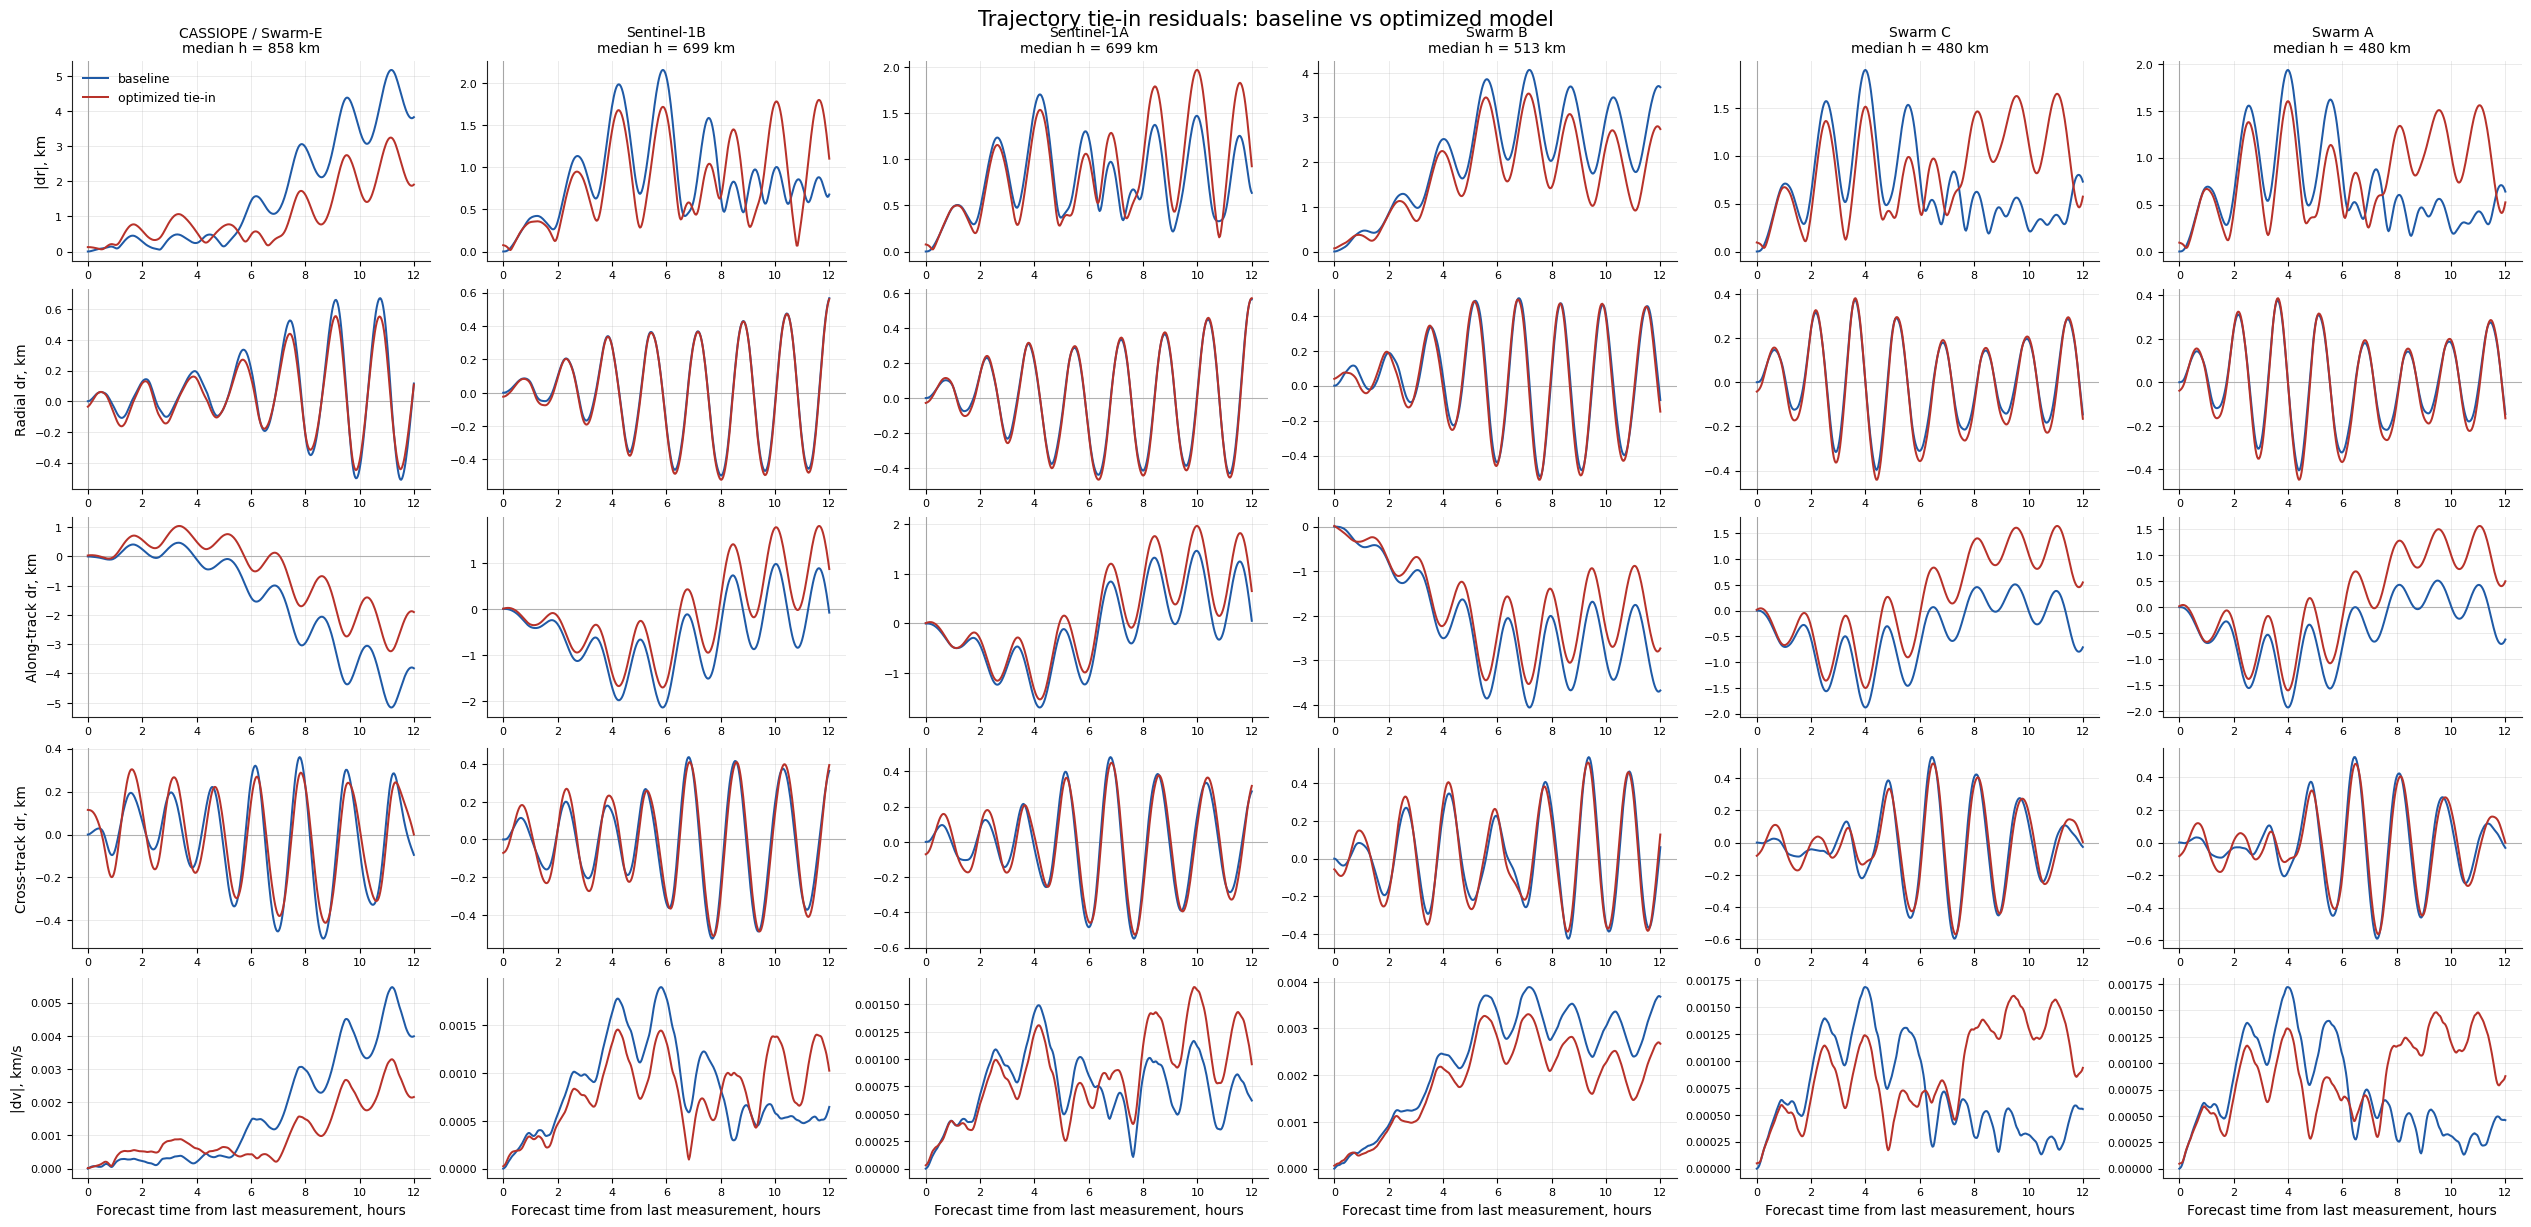

In [10]:
METRIC_ROWS = [
    ('delta_r_norm_km', '|dr|, km'),
    ('delta_radial_km', 'Radial dr, km'),
    ('delta_along_km', 'Along-track dr, km'),
    ('delta_cross_km', 'Cross-track dr, km'),
    ('delta_v_norm_km_s', '|dv|, km/s'),
]

PLOT_STYLE = {
    'figure.facecolor': 'white',
    'axes.facecolor': 'white',
    'axes.edgecolor': '#222222',
    'axes.labelsize': 10,
    'axes.titlesize': 10,
    'xtick.labelsize': 8,
    'ytick.labelsize': 8,
    'font.size': 9,
    'legend.fontsize': 9,
}

BASELINE_COLOR = '#1f5aa6'
OPTIMIZED_COLOR = '#b8322a'


def plot_tie_in_scenario():
    n_sats = len(REFERENCE_CACHE)
    with plt.rc_context(PLOT_STYLE):
        fig, axes = plt.subplots(
            len(METRIC_ROWS),
            n_sats,
            figsize=(4.2 * n_sats, 12.0),
            sharex=False,
            constrained_layout=True,
        )
        if n_sats == 1:
            axes = axes.reshape(len(METRIC_ROWS), 1)

        for col, item in enumerate(REFERENCE_CACHE):
            baseline = BASELINE_CACHE[item['name']]['residuals']
            optimized = TIE_IN_RESULTS[item['name']]['residuals']
            for row, (metric_key, ylabel) in enumerate(METRIC_ROWS):
                ax = axes[row, col]
                ax.plot(item['forecast_hours'], baseline[metric_key], color=BASELINE_COLOR, lw=1.45, label='baseline')
                ax.plot(item['forecast_hours'], optimized[metric_key], color=OPTIMIZED_COLOR, lw=1.45, label='optimized tie-in')
                ax.axvline(0.0, color='#333333', lw=0.8, alpha=0.45, zorder=0)
                if metric_key in {'delta_radial_km', 'delta_along_km', 'delta_cross_km'}:
                    ax.axhline(0.0, color='#555555', lw=0.8, alpha=0.45, zorder=0)
                ax.grid(True, alpha=0.25, linewidth=0.7)
                ax.spines['top'].set_visible(False)
                ax.spines['right'].set_visible(False)
                if col == 0:
                    ax.set_ylabel(ylabel)
                if row == len(METRIC_ROWS) - 1:
                    ax.set_xlabel('Forecast time from last measurement, hours')
                if row == 0:
                    title = item['name'] + '\n' + f'median h = {item["median_altitude_km"]:.0f} km'
                    ax.set_title(title)
                if row == 0 and col == 0:
                    ax.legend(frameon=False, loc='upper left')

        fig.suptitle('Trajectory tie-in residuals: baseline vs optimized model', fontsize=15, y=1.01)
        plt.show()


plot_tie_in_scenario()

## Numerical summary

This table is a compact reproducibility check for the figure above.

In [11]:
for item in REFERENCE_CACHE:
    baseline = BASELINE_CACHE[item['name']]['residuals']
    optimized = TIE_IN_RESULTS[item['name']]['residuals']
    print(
        f"{item['name']}: "
        f"max |dr| baseline={baseline['delta_r_norm_km'].max():.3f} km, "
        f"optimized={optimized['delta_r_norm_km'].max():.3f} km; "
        f"final |dr| baseline={baseline['delta_r_norm_km'][-1]:.3f} km, "
        f"optimized={optimized['delta_r_norm_km'][-1]:.3f} km; "
        f"period check error={item['period_rel_error']:.2%}"
    )

CASSIOPE / Swarm-E: max |dr| baseline=5.172 km, optimized=3.244 km; final |dr| baseline=3.827 km, optimized=1.905 km; period check error=0.22%
Sentinel-1B: max |dr| baseline=2.160 km, optimized=1.803 km; final |dr| baseline=0.678 km, optimized=1.105 km; period check error=0.36%
Sentinel-1A: max |dr| baseline=1.706 km, optimized=1.971 km; final |dr| baseline=0.637 km, optimized=0.926 km; period check error=0.19%
Swarm B: max |dr| baseline=4.064 km, optimized=3.535 km; final |dr| baseline=3.677 km, optimized=2.740 km; period check error=0.41%
Swarm C: max |dr| baseline=1.894 km, optimized=1.645 km; final |dr| baseline=0.729 km, optimized=0.572 km; period check error=0.25%
Swarm A: max |dr| baseline=1.934 km, optimized=1.602 km; final |dr| baseline=0.638 km, optimized=0.524 km; period check error=0.25%


## Limitations

* The selected tracking line is only a sampling heuristic; no latitude/longitude residual is included in the loss function.
* Historical measurements are nearest native records, so the event time is quantized by the source cadence.
* The observation sigmas are assumed weights, not measured covariances.
* Two measurements constrain only a short arc; ballistic parameters can remain weakly observable and are regularized by log-space priors.